In [96]:
%matplotlib inline
import sqlite3
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import binomtest, ks_2samp
from statsmodels.stats.proportion import proportion_confint as wilson
from IPython.display import display, HTML

# ── Database connections ──
DB_PATH = Path("data/corpus_baseline_onemonth.db")
DB_DIR  = DB_PATH.parent

db_paths = {
    "may_sept_2021":     DB_DIR / "famotidine_loratadine_prednisone_may_sept_2021.db",
    "4mo_pre_stop_pasc": DB_DIR / "paxlovid_pre_stop_pasc_4mo.db",
    "year_2021":         DB_DIR / "colchicine_naltrexone_year_2021.db",
    "jan_2022":          DB_DIR / "naltrexone_jan_2022.db",
    "polina_onemonth":   DB_PATH,
}
slices = {k: sqlite3.connect(str(v)) for k, v in db_paths.items()}

# ── Dedup ranking ──
SENT_RANK = {"positive": 3, "mixed": 2, "neutral": 1, "negative": 0}
SIG_RANK  = {"strong": 2, "moderate": 1, "weak": 0, "n/a": 0, None: 0, "": 0}
cutoff_2021_10 = 1633046400  # 2021-10-01 UTC (Glynne publication)

def best_per_user_drug(c, where_extra="", params=()):
    rows = c.execute(f'''
        SELECT tr.user_id, lower(t.canonical_name), tr.sentiment, tr.signal_strength, p.post_date
        FROM treatment_reports tr
        JOIN treatment t ON tr.drug_id = t.id
        JOIN posts p ON tr.post_id = p.post_id
        WHERE 1=1 {where_extra}
    ''', params).fetchall()
    best = {}
    for uid, drug, sent, sig, _d in rows:
        k = (SENT_RANK.get(sent, -1), SIG_RANK.get(sig, 0))
        key = (uid, drug)
        if key not in best or k > best[key][0]:
            best[key] = (k, sent, drug)
    return list(best.values())

def cohens_h(p1, p2):
    return 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))

def _sentiment_breakdown(drug_label, sentiments, trial_dir, paper_ref):
    n = len(sentiments)
    pos  = sum(1 for s in sentiments if s == "positive")
    neg  = sum(1 for s in sentiments if s == "negative")
    neu  = sum(1 for s in sentiments if s == "neutral")
    mix  = sum(1 for s in sentiments if s == "mixed")
    nonr = neg + neu + mix
    pos_lo,  pos_hi  = wilson(pos,  n, alpha=0.05, method="wilson") if n else (0, 0)
    nonr_lo, nonr_hi = wilson(nonr, n, alpha=0.05, method="wilson") if n else (0, 0)
    pval = binomtest(pos, n, 0.5, alternative="two-sided").pvalue if n else 1.0
    h = cohens_h(pos/n, 0.5) if n else 0.0
    return {
        "drug": drug_label, "n": n, "trial_dir": trial_dir, "paper": paper_ref,
        "pos": pos, "neg": neg, "neu": neu, "mix": mix, "nonr": nonr,
        "pos_pct":  pos/n*100  if n else 0,
        "pos_lo":   pos_lo*100,  "pos_hi":  pos_hi*100,
        "nonr_pct": nonr/n*100 if n else 0,
        "nonr_lo":  nonr_lo*100, "nonr_hi": nonr_hi*100,
        "pval": pval, "h": h,
    }

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12


In [97]:
drug_specs = [
    ("famotidine",  "may_sept_2021",     "AND p.post_date < ?", (cutoff_2021_10,), "+", "Glynne 2021"),
    ("loratadine",  "may_sept_2021",     "AND p.post_date < ?", (cutoff_2021_10,), "+", "Glynne 2021"),
    ("prednisone",  "may_sept_2021",     "AND p.post_date < ?", (cutoff_2021_10,), "0", "2024 meta-analysis"),
    ("paxlovid",    "4mo_pre_stop_pasc", "", (), "0", "STOP-PASC 2024"),
    ("colchicine",  "year_2021",         "", (), "0", "Bassi 2025"),
]

binary_scores = {}
resp_rows = []

for drug, sl, wx, p, td, ref in drug_specs:
    recs = best_per_user_drug(slices[sl], wx, p)
    recs = [r for r in recs if r[2] == drug]
    sents = [r[1] for r in recs]
    resp_rows.append(_sentiment_breakdown(drug, sents, td, ref))
    binary_scores[drug] = [1 if s == "positive" else 0 for s in sents]

# Naltrexone: combined across year_2021 + jan_2022
def _nalt_recs(slice_key):
    return slices[slice_key].execute('''
        SELECT tr.user_id, tr.sentiment, tr.signal_strength
        FROM treatment_reports tr JOIN treatment t ON tr.drug_id = t.id
        WHERE lower(t.canonical_name) IN ('naltrexone', 'low dose naltrexone', 'ldn')
    ''').fetchall()

nalt_best = {}
for uid, sent, sig in _nalt_recs("year_2021") + _nalt_recs("jan_2022"):
    k = (SENT_RANK.get(sent, -1), SIG_RANK.get(sig, 0))
    if uid not in nalt_best or k > nalt_best[uid][0]:
        nalt_best[uid] = (k, sent)

nalt_sents = [v[1] for v in nalt_best.values()]
resp_rows.append(_sentiment_breakdown("naltrexone", nalt_sents, "+", "O'Kelly 2022"))
binary_scores["naltrexone"] = [1 if s == "positive" else 0 for s in nalt_sents]

resp_df = (pd.DataFrame(resp_rows)
           .sort_values("pos_pct", ascending=False)
           .reset_index(drop=True))

print(resp_df[["drug", "n", "pos_pct", "pval", "trial_dir"]].to_string(index=False))


      drug   n   pos_pct         pval trial_dir
famotidine 207 78.743961 2.880285e-17         +
loratadine 107 68.224299 2.063747e-04         +
naltrexone  76 65.789474 7.905180e-03         +
colchicine  40 62.500000 1.538599e-01         0
  paxlovid 153 52.287582 6.277709e-01         0
prednisone 176 52.272727 5.978724e-01         0


In [105]:
ax.text?

Signature: ax.text(x, y, s, fontdict=None, **kwargs)
Docstring:
Add text to the Axes.

Add the text *s* to the Axes at location *x*, *y* in data coordinates,
with a default ``horizontalalignment`` on the ``left`` and
``verticalalignment`` at the ``baseline``. See
:doc:`/gallery/text_labels_and_annotations/text_alignment`.

Parameters
----------
x, y : float
    The position to place the text. By default, this is in data
    coordinates. The coordinate system can be changed using the
    *transform* parameter.

s : str
    The text.

fontdict : dict, default: None

    .. admonition:: Discouraged

       The use of *fontdict* is discouraged. Parameters should be passed as
       individual keyword arguments or using dictionary-unpacking
       ``text(..., **fontdict)``.

    A dictionary to override the default text properties. If fontdict
    is None, the defaults are determined by `.rcParams`.

Returns
-------
`.Text`
    The created `.Text` instance.

Other Parameters
---------------

In [120]:
plt.subplots?

Signature:
plt.subplots(
    nrows: 'int' = 1,
    ncols: 'int' = 1,
    *,
    sharex: "bool | Literal['none', 'all', 'row', 'col']" = False,
    sharey: "bool | Literal['none', 'all', 'row', 'col']" = False,
    squeeze: 'bool' = True,
    width_ratios: 'Sequence[float] | None' = None,
    height_ratios: 'Sequence[float] | None' = None,
    subplot_kw: 'dict[str, Any] | None' = None,
    gridspec_kw: 'dict[str, Any] | None' = None,
    **fig_kw,
) -> 'tuple[Figure, Any]'
Docstring:
Create a figure and a set of subplots.

This utility wrapper makes it convenient to create common layouts of
subplots, including the enclosing figure object, in a single call.

Parameters
----------
nrows, ncols : int, default: 1
    Number of rows/columns of the subplot grid.

sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
    Controls sharing of properties among x (*sharex*) or y (*sharey*)
    axes:

    - True or 'all': x- or y-axis will be shared among all subplots.
    - False

Figure 1 — Pre-publication community sentiment: responders vs non-responders by drug


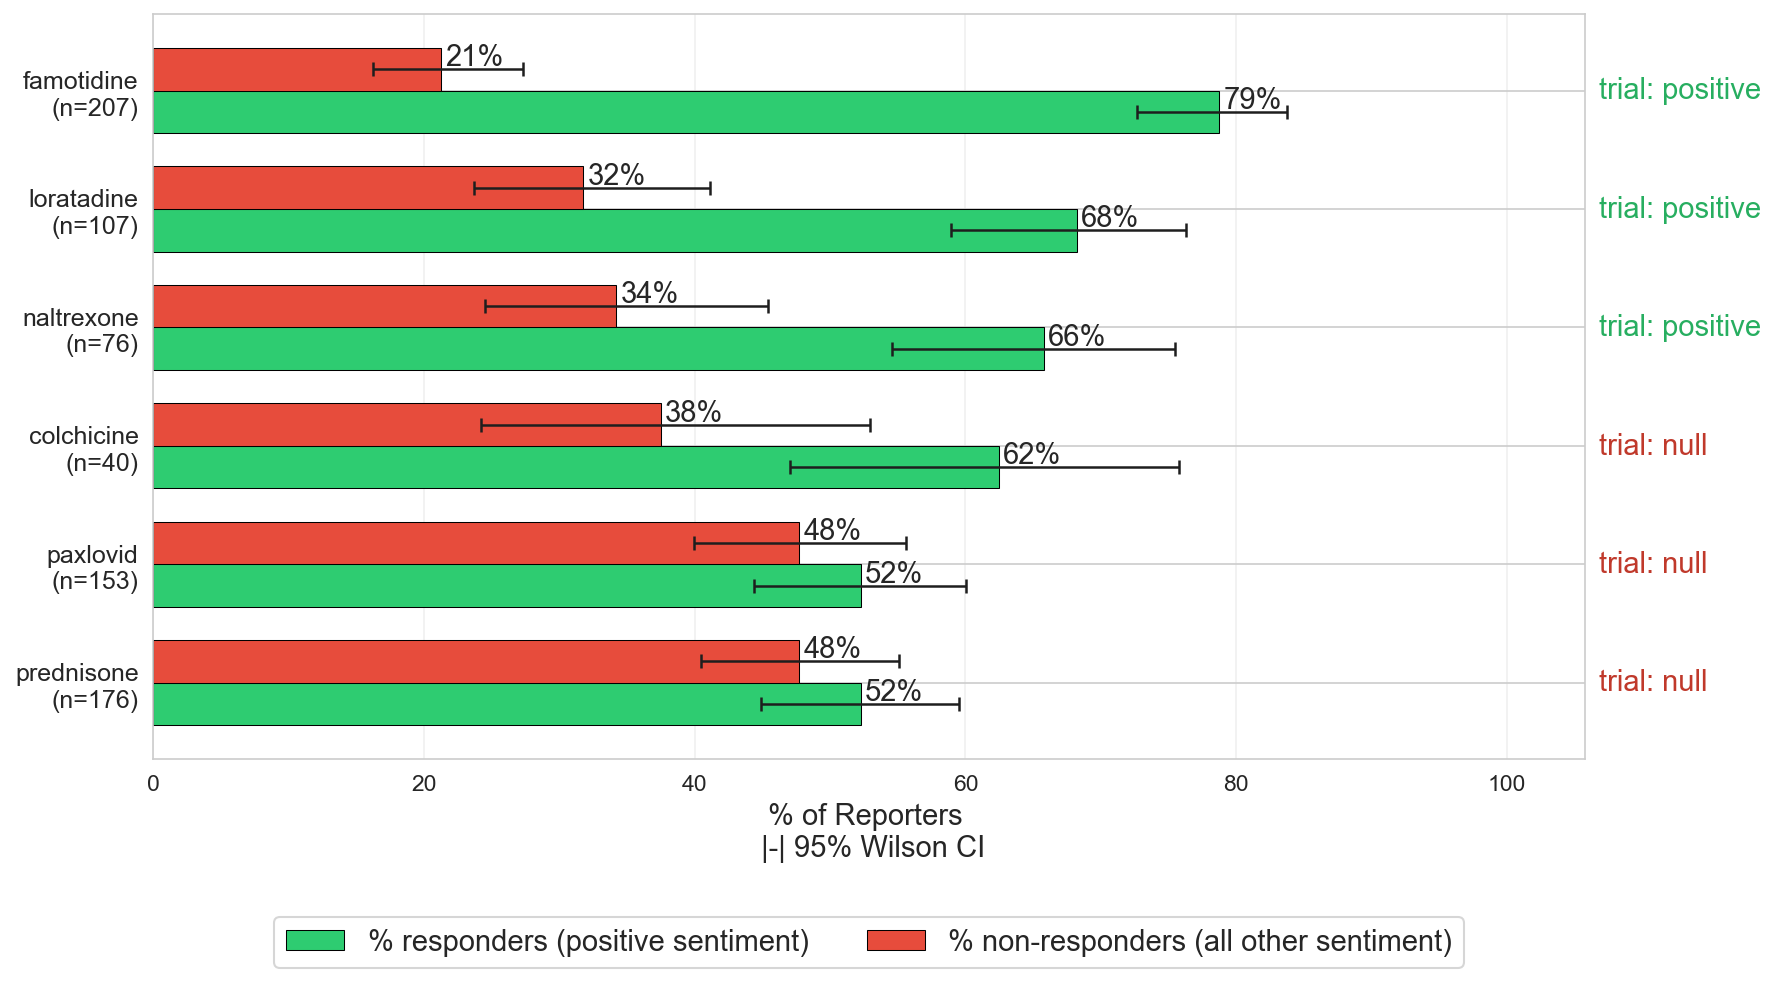

In [128]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6.8), dpi=150)
y = np.arange(len(resp_df))[::-1]
bar_h = 0.36

ax.barh(y - bar_h/2, resp_df["pos_pct"], height=bar_h,
        color="#2ecc71", edgecolor="black", linewidth=0.5,
        label="% responders (positive)")
ax.errorbar(resp_df["pos_pct"], y - bar_h/2,
            xerr=[resp_df["pos_pct"] - resp_df["pos_lo"],
                  resp_df["pos_hi"] - resp_df["pos_pct"]],
            fmt="none", ecolor="#1e1e1e", elinewidth=1.2, capsize=3.5, capthick=1.2)

ax.barh(y + bar_h/2, resp_df["nonr_pct"], height=bar_h,
        color="#e74c3c", edgecolor="black", linewidth=0.5,
        label="% non-responders (neg + neu + mix)")
ax.errorbar(resp_df["nonr_pct"], y + bar_h/2,
            xerr=[resp_df["nonr_pct"] - resp_df["nonr_lo"],
                  resp_df["nonr_hi"] - resp_df["nonr_pct"]],
            fmt="none", ecolor="#1e1e1e", elinewidth=1.2, capsize=3.5, capthick=1.2)

for i, r in resp_df.iterrows():
    ax.text(r["pos_pct"]  + 0.3, .1 + y[i] - bar_h/2, f"{r['pos_pct']:.0f}%",  va="center", ha="left", fontsize=14)
    ax.text(r["nonr_pct"] + 0.3, .1 + y[i] + bar_h/2, f"{r['nonr_pct']:.0f}%", va="center", ha="left", fontsize=14)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['drug']}\n(n={r['n']})" for _, r in resp_df.iterrows()], fontsize=12)
ax.set_xlim(0, max(resp_df["pos_hi"].max(), resp_df["nonr_hi"].max()) + 22)
ax.set_xlabel("% of Reporters \n |-| 95% Wilson CI", fontsize=14)

# In our paper, this should be Document Text rather than embedded in image
print("Figure 1 — Pre-publication community sentiment: responders vs non-responders by drug")
# ax.set_title("Figure 1 — Pre-publication community sentiment: responders vs non-responders by drug",
#              fontsize=14, fontweight="bold")

ax.tick_params(axis="x", labelsize=11)
ax.grid(axis="x", alpha=0.3)

TAG_STYLE = {"+": ("trial: positive", "#27ae60"), "0": ("trial: null", "#c0392b")}
for i, r in resp_df.iterrows():
    label, color = TAG_STYLE.get(r["trial_dir"], (f"trial: {r['trial_dir']}", "#7f8c8d"))
    ax.text(1.01, y[i], label, transform=ax.get_yaxis_transform(),
            va="center", ha="left", fontsize=14, family="sans-serif",
            color=color)

legend_elems = [
    Patch(facecolor="#2ecc71", edgecolor="black", linewidth=0.5, label="% responders (positive sentiment)"),
    Patch(facecolor="#e74c3c", edgecolor="black", linewidth=0.5, label="% non-responders (all other sentiment)"),
]
ax.legend(handles=legend_elems, loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=14)
plt.tight_layout()
plt.show()


In [92]:
_src_rows = [
    ("famotidine",  "famotidine_loratadine_prednisone_may_sept_2021",         "2021-05-01", "2021-09-30",  88077, 207, 493, "Glynne et al. Oct 2021"),
    ("loratadine",  "famotidine_loratadine_prednisone_may_sept_2021",         "2021-05-01", "2021-09-30",  88077, 107, 222, "Glynne et al. Oct 2021"),
    ("prednisone",  "famotidine_loratadine_prednisone_may_sept_2021",         "2021-05-01", "2021-09-30",  88077, 176, 374, "Utrero-Rico et al. 2021"),
    ("paxlovid",    "paxlovid_pre_stop_pasc_4mo",                            "2024-03-01", "2024-06-06", 106889, 153, 341, "STOP-PASC Jun 2024"),
    ("colchicine",  "colchicine_naltrexone_year_2021",                       "2021-01-01", "2021-12-31", 217866,  40, 103, "Bassi et al. 2025"),
    ("naltrexone",  "colchicine_naltrexone_year_2021 + naltrexone_jan_2022", "2021-01-01", "2022-01-30", 244036,  76, 270, "O'Kelly et al. Jul 2022"),
]
src_df = pd.DataFrame(_src_rows, columns=["drug", "database", "window_start", "window_end",
                                           "total_posts", "unique_users", "treatment_reports", "trial_cutoff"])

src_html = "<table style='border-collapse:collapse; width:100%; font-size:0.9em; margin:12px 0;'>"
src_html += ("<tr style='background:#34495e; color:white;'>"
             "<th style='padding:6px 10px;'>Drug</th><th style='padding:6px 10px;'>Database</th>"
             "<th style='padding:6px 10px;'>Window</th><th style='padding:6px 10px;'>Total posts</th>"
             "<th style='padding:6px 10px;'>Unique users</th><th style='padding:6px 10px;'>Reports</th>"
             "<th style='padding:6px 10px;'>Pre-pub cutoff</th></tr>")
for i, (_, r) in enumerate(src_df.iterrows()):
    bg = "#fff" if i % 2 == 0 else "#f8f9fa"
    src_html += (f"<tr style='background:{bg};'>"
                 f"<td style='padding:6px 10px; font-weight:bold;'>{r['drug']}</td>"
                 f"<td style='padding:6px 10px; font-size:0.85em;'>{r['database']}</td>"
                 f"<td style='padding:6px 10px;'>{r['window_start']} to {r['window_end']}</td>"
                 f"<td style='padding:6px 10px; text-align:center;'>{r['total_posts']:,}</td>"
                 f"<td style='padding:6px 10px; text-align:center;'>{r['unique_users']}</td>"
                 f"<td style='padding:6px 10px; text-align:center;'>{r['treatment_reports']}</td>"
                 f"<td style='padding:6px 10px; font-size:0.85em;'>{r['trial_cutoff']}</td></tr>")
src_html += "</table>"
display(HTML("<h3>Table 2 — Data sources by drug</h3>" + src_html))


Drug,Database,Window,Total posts,Unique users,Reports,Pre-pub cutoff
famotidine,famotidine_loratadine_prednisone_may_sept_2021,2021-05-01 to 2021-09-30,"88,077",207,493,Glynne et al. Oct 2021
loratadine,famotidine_loratadine_prednisone_may_sept_2021,2021-05-01 to 2021-09-30,"88,077",107,222,Glynne et al. Oct 2021
prednisone,famotidine_loratadine_prednisone_may_sept_2021,2021-05-01 to 2021-09-30,"88,077",176,374,Utrero-Rico et al. 2021
paxlovid,paxlovid_pre_stop_pasc_4mo,2024-03-01 to 2024-06-06,"106,889",153,341,STOP-PASC Jun 2024
colchicine,colchicine_naltrexone_year_2021,2021-01-01 to 2021-12-31,"217,866",40,103,Bassi et al. 2025
naltrexone,colchicine_naltrexone_year_2021 + naltrexone_jan_2022,2021-01-01 to 2022-01-30,"244,036",76,270,O'Kelly et al. Jul 2022


In [ ]:
table_df = resp_df[["drug", "trial_dir", "paper", "n", "pos", "pos_pct", "pos_lo", "pos_hi",
                    "nonr", "nonr_pct", "nonr_lo", "nonr_hi", "mix", "pval", "h"]].copy()

def _fmt_pct(v): return f"{v:.1f}%"
def _fmt_ci(lo, hi): return f"[{lo:.1f}%, {hi:.1f}%]"
def _fmt_p(v): return f"{v:.4f}" if v >= 0.001 else f"{v:.2e}"

table_df["% responders"]      = table_df["pos_pct"].apply(_fmt_pct)
table_df["95% CI"]            = [_fmt_ci(lo, hi) for lo, hi in zip(table_df["pos_lo"], table_df["pos_hi"])]
table_df["% non-resp"]        = table_df["nonr_pct"].apply(_fmt_pct)
table_df["non-resp 95% CI"]   = [_fmt_ci(lo, hi) for lo, hi in zip(table_df["nonr_lo"], table_df["nonr_hi"])]
table_df["p (vs 50%)"]        = table_df["pval"].apply(_fmt_p)
table_df["Cohen's h"]         = table_df["h"].apply(lambda v: f"{v:.3f}")

display_cols = ["drug", "paper", "n", "% responders", "95% CI", "% non-resp", "non-resp 95% CI", "p (vs 50%)", "Cohen's h"]
display_df = table_df[display_cols].rename(columns={"drug": "Drug", "paper": "Trial ref", "n": "N"})
display(HTML("<h3>Table 3 — Per-drug response composition (pre-publication data only)</h3>"
             + display_df.to_html(index=False)))


KS test (positive-trial vs null-trial pools)
  D = 0.1995,  p = 0.0000
  positive-trial mean: 0.733  (n=390)
  null-trial mean:     0.534  (n=369)


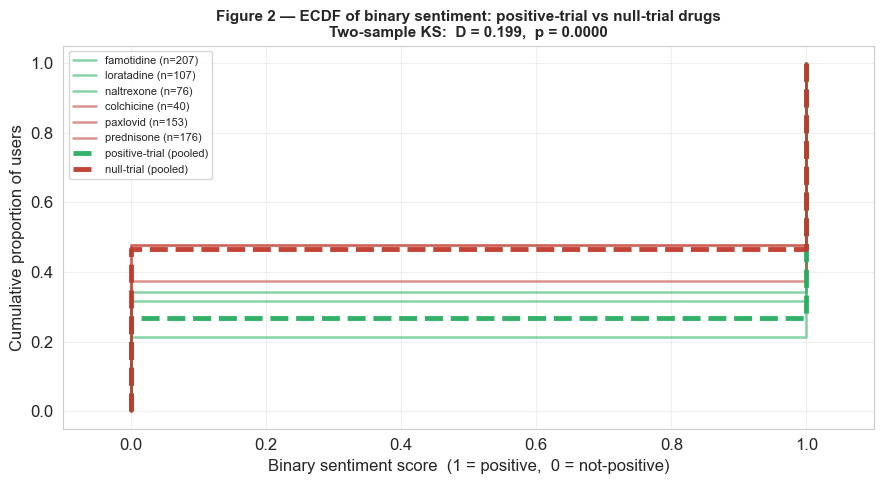

In [93]:
# Pool binary scores by trial outcome
pos_trial_pool = np.concatenate([
    binary_scores[r["drug"]] for _, r in resp_df.iterrows() if r["trial_dir"] == "+"
])
null_trial_pool = np.concatenate([
    binary_scores[r["drug"]] for _, r in resp_df.iterrows() if r["trial_dir"] == "0"
])

ks_stat, ks_pval = ks_2samp(pos_trial_pool, null_trial_pool)
print(f"KS test (positive-trial vs null-trial pools)")
print(f"  D = {ks_stat:.4f},  p = {ks_pval:.4f}")
print(f"  positive-trial mean: {pos_trial_pool.mean():.3f}  (n={len(pos_trial_pool)})")
print(f"  null-trial mean:     {null_trial_pool.mean():.3f}  (n={len(null_trial_pool)})")

def ecdf(arr):
    x = np.sort(arr)
    y = np.arange(1, len(x) + 1) / len(x)
    return np.concatenate([[x[0]], x]), np.concatenate([[0.0], y])

TRIAL_COLOR = {"+": "#27ae60", "0": "#c0392b"}

fig, ax = plt.subplots(figsize=(9, 5))

for _, r in resp_df.iterrows():
    x, y = ecdf(np.array(binary_scores[r["drug"]], dtype=float))
    ax.step(x, y, where="post", color=TRIAL_COLOR[r["trial_dir"]],
            alpha=0.55, linewidth=1.8, label=f"{r['drug']} (n={r['n']})")

for pool, label, color in [
    (pos_trial_pool, "positive-trial (pooled)", "#27ae60"),
    (null_trial_pool, "null-trial (pooled)",    "#c0392b"),
]:
    x, y = ecdf(pool.astype(float))
    ax.step(x, y, where="post", color=color, linewidth=3.5,
            linestyle="--", alpha=0.95, label=label)

ax.set_xlim(-0.1, 1.1)
ax.set_xlabel("Binary sentiment score  (1 = positive,  0 = not-positive)")
ax.set_ylabel("Cumulative proportion of users")
ax.set_title(
    f"Figure 2 — ECDF of binary sentiment: positive-trial vs null-trial drugs\n"
    f"Two-sample KS:  D = {ks_stat:.3f},  p = {ks_pval:.4f}",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## KS test interpretation

The two-sample Kolmogorov–Smirnov test compares the empirical cumulative distribution
functions (ECDFs) of binary sentiment scores between:

- **Positive-trial pool** (famotidine + loratadine + naltrexone): users who mentioned a
  drug that later showed a positive RCT outcome
- **Null-trial pool** (prednisone + paxlovid + colchicine): users who mentioned a drug
  that later showed a null RCT outcome

The KS **D-statistic** is the maximum vertical gap between the two pooled ECDFs.
For binary data (scores ∈ {0, 1}), D equals the absolute difference in positive rates
between the two pools.

A significant p-value means the two pools are drawn from different distributions —
i.e., community sentiment was systematically more positive for drugs that later succeeded
in trials than for drugs that failed.


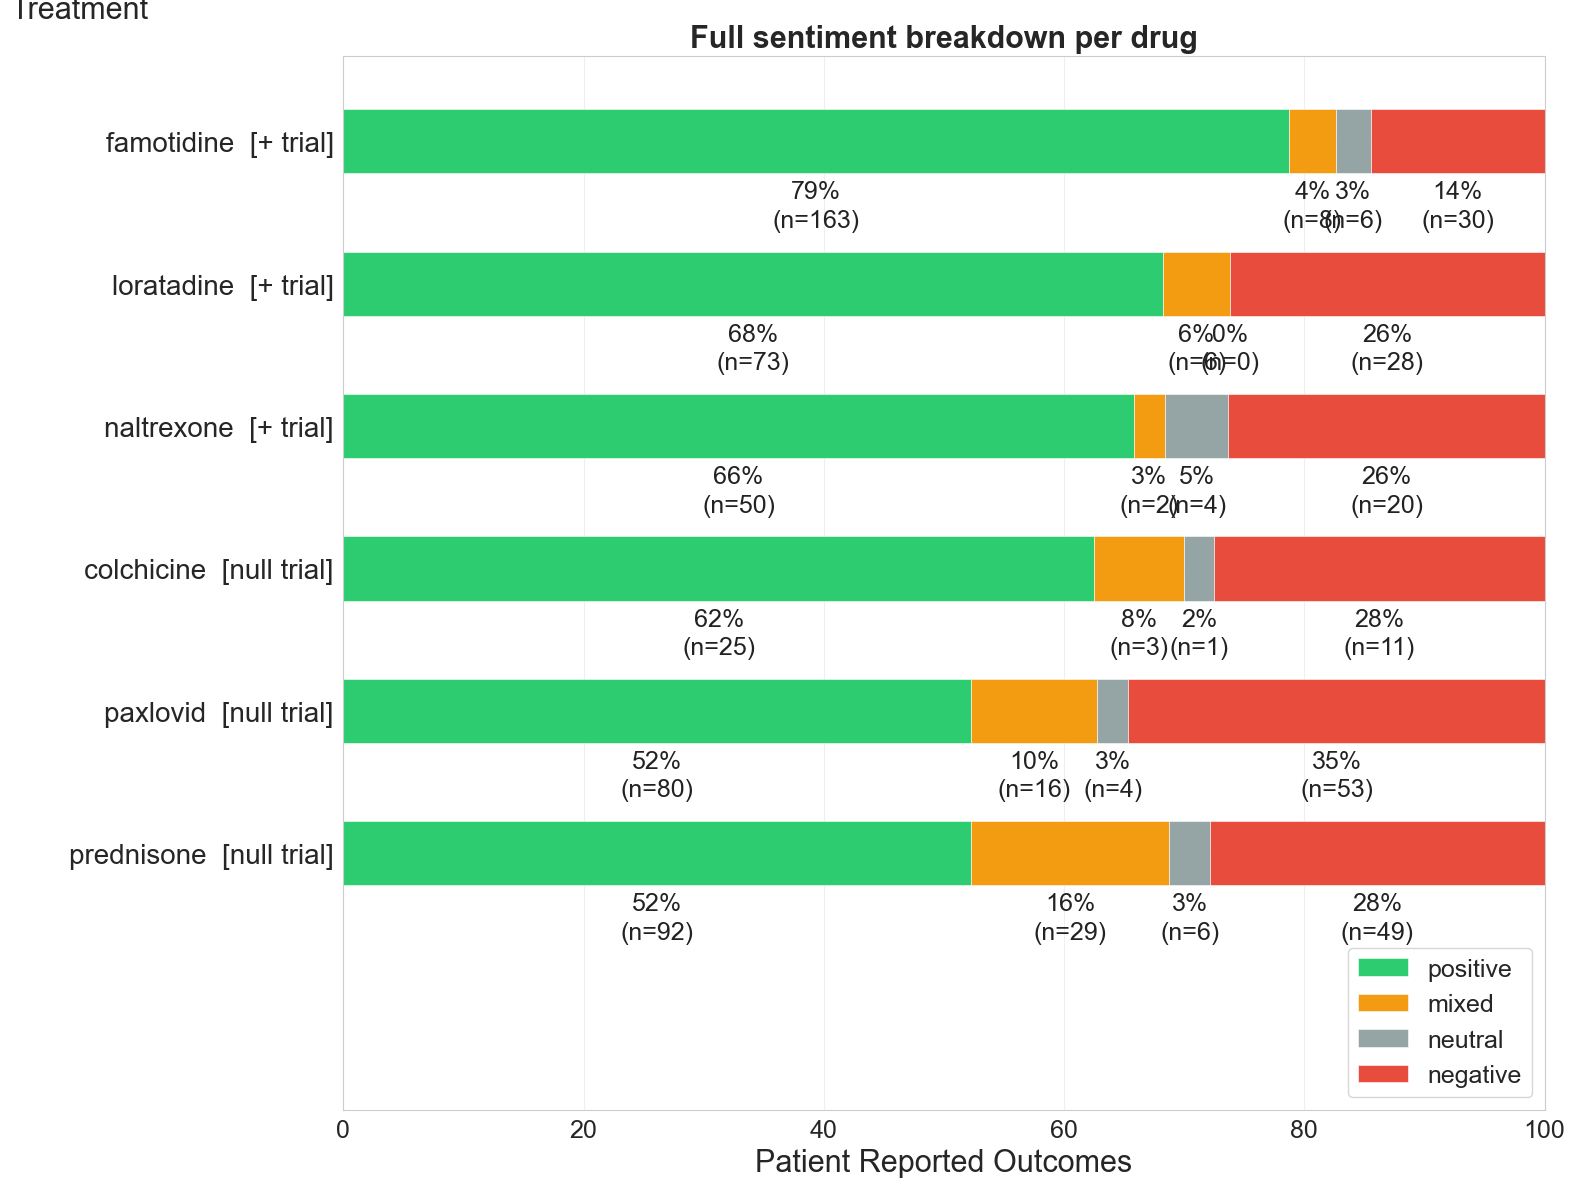

In [94]:
# Stacked bar: positive / mixed / neutral / negative per drug
cats   = ["positive", "mixed", "neutral", "negative"]
colors = ["#2ecc71",  "#f39c12", "#95a5a6", "#e74c3c"]

pcts = pd.DataFrame({
    "drug":     resp_df["drug"],
    "trial":    resp_df["trial_dir"],
    "positive": resp_df["pos"]  / resp_df["n"] * 100,
    "mixed":    resp_df["mix"]  / resp_df["n"] * 100,
    "neutral":  resp_df["neu"]  / resp_df["n"] * 100,
    "negative": resp_df["neg"]  / resp_df["n"] * 100,
})
raw = {"positive": resp_df["pos"].values, "mixed": resp_df["mix"].values,
       "neutral":  resp_df["neu"].values, "negative": resp_df["neg"].values}

BAR_H   = 0.45
LABEL_Y_OFFSET = BAR_H / 2 + 0.05   # just below each bar

fig, ax = plt.subplots(figsize=(16, 12))
y = np.arange(len(pcts))[::-1]

# Draw bars
left = np.zeros(len(pcts))
for cat, color in zip(cats, colors):
    vals = pcts[cat].values
    ax.barh(y, vals, left=left, height=BAR_H, color=color, label=cat,
            edgecolor="white", linewidth=0.4)
    left += vals

# Labels below each bar segment
for row_i, yi in enumerate(y):
    left_x = 0.0
    for cat, color in zip(cats, colors):
        pct = pcts[cat].values[row_i]
        n   = raw[cat][row_i]
        cx  = left_x + pct / 2
        ax.text(cx, yi - LABEL_Y_OFFSET, f"{pct:.0f}%\n(n={n})",
                ha="center", va="top", fontsize=18, color="#222",
                linespacing=1.3)
        left_x += pct

ax.set_yticks(y)
ax.set_yticklabels([f"{r['drug']}  [{'+ trial' if r['trial'] == '+' else 'null trial'}]"
                    for _, r in pcts.iterrows()], fontsize=20)
ax.set_xlabel("Patient Reported Outcomes", fontsize=22)
ax.set_xlim(0, 100)
ax.set_ylim(y.min() - 1.8, y.max() + 0.6)
ax.set_title("Full sentiment breakdown per drug",
             fontsize=22, fontweight="bold")
ax.legend(loc="lower right", fontsize=18)
ax.set_ylabel("Treatment", fontsize=22, rotation=0, ha="center")
ax.yaxis.set_label_coords(-0.22, 1.03)
ax.tick_params(axis="x", labelsize=18)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


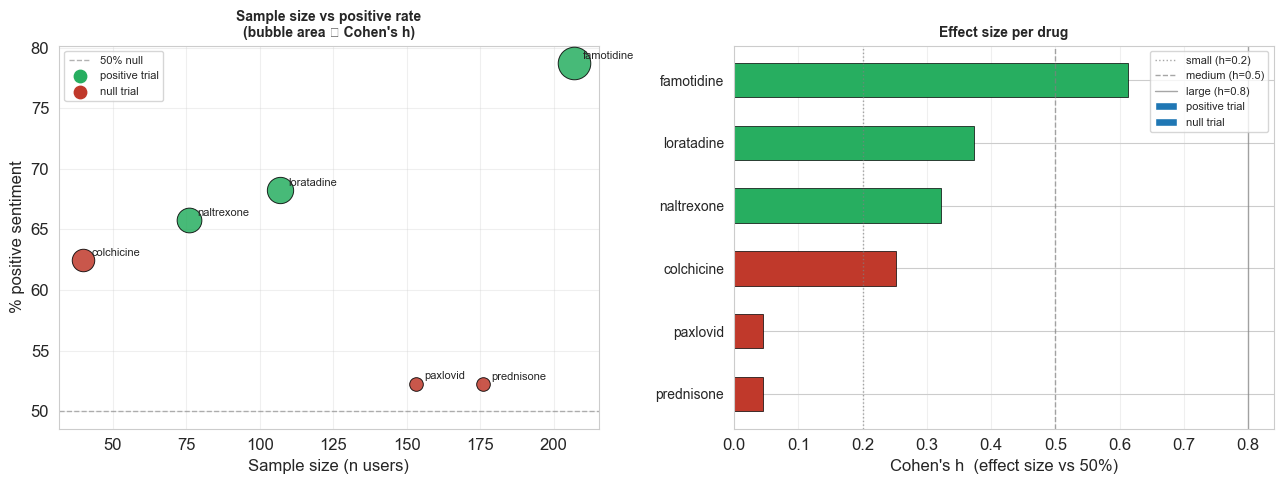

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

TRIAL_COLOR = {"+": "#27ae60", "0": "#c0392b"}
TRIAL_LABEL = {"+": "positive trial", "0": "null trial"}

# Left: n vs positive rate, bubble sized by Cohen's h
ax = axes[0]
for _, r in resp_df.iterrows():
    color = TRIAL_COLOR[r["trial_dir"]]
    ax.scatter(r["n"], r["pos_pct"], s=r["h"]*800 + 60,
               color=color, edgecolors="black", linewidth=0.7, alpha=0.85, zorder=3)
    ax.annotate(r["drug"], (r["n"], r["pos_pct"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

ax.axhline(50, color="grey", linestyle="--", linewidth=1, alpha=0.6, label="50% null")
ax.set_xlabel("Sample size (n users)")
ax.set_ylabel("% positive sentiment")
ax.set_title("Sample size vs positive rate\n(bubble area ∝ Cohen's h)", fontsize=10, fontweight="bold")
ax.grid(alpha=0.3)
for td, lbl in TRIAL_LABEL.items():
    ax.scatter([], [], color=TRIAL_COLOR[td], s=80, label=lbl)
ax.legend(fontsize=8)

# Right: Cohen's h bar chart
ax = axes[1]
order = resp_df.sort_values("h", ascending=True)
y2 = np.arange(len(order))
bar_colors = [TRIAL_COLOR[t] for t in order["trial_dir"]]
bars = ax.barh(y2, order["h"], color=bar_colors, edgecolor="black", linewidth=0.5, height=0.55)
ax.set_yticks(y2)
ax.set_yticklabels(order["drug"], fontsize=10)
ax.set_xlabel("Cohen's h  (effect size vs 50%)")
ax.set_title("Effect size per drug", fontsize=10, fontweight="bold")
ax.axvline(0.2, color="grey", linestyle=":", linewidth=1, alpha=0.7, label="small (h=0.2)")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="medium (h=0.5)")
ax.axvline(0.8, color="grey", linestyle="-",  linewidth=1, alpha=0.7, label="large (h=0.8)")
for td, lbl in TRIAL_LABEL.items():
    ax.barh([], [], color=TRIAL_COLOR[td], label=lbl)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Strip plot: individual user binary scores jittered per drug
fig, ax = plt.subplots(figsize=(11, 5))

TRIAL_COLOR = {"+": "#27ae60", "0": "#c0392b"}
drugs_ordered = list(resp_df["drug"])

for xi, (_, r) in enumerate(resp_df.iterrows()):
    scores = np.array(binary_scores[r["drug"]], dtype=float)
    jitter = np.random.default_rng(xi).uniform(-0.25, 0.25, len(scores))
    color  = TRIAL_COLOR[r["trial_dir"]]
    ax.scatter(xi + jitter, scores, alpha=0.15, s=12, color=color)
    # Mean line
    ax.hlines(scores.mean(), xi - 0.35, xi + 0.35, colors=color, linewidth=2.5)
    ax.text(xi, scores.mean() + 0.04, f"{scores.mean():.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", color=color)

ax.set_xticks(range(len(drugs_ordered)))
ax.set_xticklabels(drugs_ordered, fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["not-positive (0)", "positive (1)"])
ax.set_ylabel("Binary sentiment score")
ax.set_title("Individual user scores per drug  (line = mean positive rate)",
             fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for td, lbl in {"+": "positive trial", "0": "null trial"}.items():
    ax.scatter([], [], color=TRIAL_COLOR[td], s=40, label=lbl)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
